# Applied Machine Learning: In-class Exercise 03-1

## Goal

Learn how to perform preprocessing steps using `sklearn.preprocessing` and how to combine preprocessing with a learner to create a sklearn `Pipeline` that first applies the preprocessing and then trains a learner.

## German Credit Data

### Description
* Data from 1973 to 1975 from a large regional bank in southern Germany classifying credits described by a set of attributes to good or bad credit risks.

* Stratified sample of 1000 credits (300 bad ones and 700 good ones).

* Customers with good credit risks perfectly complied with the conditions of the contract while customers with bad credit risks did not comply with the contract as required.

* The dataset is available from OpenML as "credit-g".


### Data Dictionary
n = 1,000 observations of credits
* credit_risk: Has the credit contract been complied with (good) or not (bad)?
* age: Age of debtor in years
* amount: Credit amount in DM
* credit_history: History of compliance with previous or concurrent credit contracts
* duration: Credit duration in months
* employment_duration: Duration of debtor’s employment with current employer
* foreign_worker: Whether the debtor is a foreign worker
* housing: Type of housing the debtor lives in
* installment_rate: Credit installments as a percentage of debtor’s disposable income
* job: Quality of debtor’s job
* number_credits: Number of credits including the current one the debtor has (or had) at this bank
* other_debtors: Whether there is another debtor or a guarantor for the credit
* other_installment_plans: Installment plans from providers other than the credit-giving bank
* people_liable: Number of persons who financially depend on the debtor
* personal_status_sex: Combined information on sex and marital status
* present_residence: Length of time (in years) the debtor lives in the present residence
* property: The debtor’s most valuable property
* purpose: Purpose for which the credit is needed
* savings: Debtor’s saving
* status: Status of the debtor’s checking account with the bank
* telephone: Whether there is a telephone landline registered on the debtor’s name

## Recap

We load the dataset via `fetch_openml()` from `sklearn.datasets`. This will return both the features X (a `pandas.DataFrame`) and the single-variable target y (a `pandas.Series`).
By inspecting `X.info()` we get an overview of the dataset:
It has 1000 observations and 20 features. Most features are categorical (object dtype), and some are numerical (int or float dtype), similar to the structure described in the data dictionary.
To obtain the list of feature names and types, we can inspect the `DataFrame.columns` and `DataFrame.dtypes` attributes.
To check the distribution of the target variable, we use `y.value_counts()`.

Load the dataset and perform basic data exploration. Retrieve the features $X$ and the target $y$.

In [1]:
#===SOLUTION===

import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml

X, y = fetch_openml(name="credit-g", version=1, as_frame=True, return_X_y=True)

print(f"Task: German Credit Data with {X.shape[0]} observations and {X.shape[1]} features.")
print("\nFeature data structure (info):")
print(X.info())

features = list(X.columns)
print(f"\nFeature names: {features}")

# Create a summary table of feature types
feature_types = pd.DataFrame({
    "id": features,
    "type": X.dtypes.values
})
print("\nFeature types:")
print(feature_types)

print("\nTarget class distribution:")
print(y.value_counts())

print("\nUnique class names in target:")
print(y.unique())

Task: German Credit Data with 1000 observations and 20 features.

Feature data structure (info):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   checking_status         1000 non-null   category
 1   duration                1000 non-null   int64   
 2   credit_history          1000 non-null   category
 3   purpose                 1000 non-null   category
 4   credit_amount           1000 non-null   int64   
 5   savings_status          1000 non-null   category
 6   employment              1000 non-null   category
 7   installment_commitment  1000 non-null   int64   
 8   personal_status         1000 non-null   category
 9   other_parties           1000 non-null   category
 10  residence_since         1000 non-null   int64   
 11  property_magnitude      1000 non-null   category
 12  age                     1000 non-nul

## 1 Preprocess the Dataset (with One-Hot Encoding)

Use a `ColumnTransformer` combined with `OneHotEncoder` from `scikit-learn` to convert all categorical features from the German Credit dataset into preprocessed features containing 0-1 indicator variables (dummy variables) for each category level instead of categorical features.

<details><summary>Hint 1:</summary>
In Python, `ColumnTransformer` is commonly used to apply preprocessing operations to specific columns of a dataset.  
We can identify categorical features automatically by checking for columns with `object` or `category` dtype.  
Once identified, we use `OneHotEncoder` to encode them, while numeric features are simply passed through unchanged.
</details>


In [2]:
#===SOLUTION===

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Identify categorical features (assumed to be of dtype 'object' or 'category')
cat_features = X.select_dtypes(include=["object", "category"]).columns.tolist()
# Identify numeric features to pass through
num_features = X.select_dtypes(exclude=["object", "category"]).columns.tolist()

# Create a ColumnTransformer to one-hot encode categorical features (dropping the first level to avoid collinearity)
ct = ColumnTransformer(
    transformers=[
        ("onehot", OneHotEncoder(sparse_output=False, drop="first"), cat_features)
    ],
    remainder="passthrough"
)

# Fit and transform the feature matrix
X_encoded = ct.fit_transform(X)

# Retrieve new feature names for the one-hot encoded columns
onehot_feature_names = ct.named_transformers_["onehot"].get_feature_names_out(cat_features)
# Combine one-hot encoded feature names with the names of the numeric features.
all_feature_names = np.concatenate([onehot_feature_names, num_features])

# Create a DataFrame for the transformed features
X_encoded_df = pd.DataFrame(X_encoded, columns=all_feature_names)
print(X_encoded_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 48 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   checking_status_<0                             1000 non-null   float64
 1   checking_status_>=200                          1000 non-null   float64
 2   checking_status_no checking                    1000 non-null   float64
 3   credit_history_critical/other existing credit  1000 non-null   float64
 4   credit_history_delayed previously              1000 non-null   float64
 5   credit_history_existing paid                   1000 non-null   float64
 6   credit_history_no credits/all paid             1000 non-null   float64
 7   purpose_domestic appliance                     1000 non-null   float64
 8   purpose_education                              1000 non-null   float64
 9   purpose_furniture/equipment                    1000 n

## 2 Create a Simple Pipeline (with One-Hot Encoding)

Build a pipeline that applies one-hot encoding to the categorical features, trains an XGBoost classifier on the preprocessed data, and makes predictions on the training set.

Additionally, note that we need to encode the target manually, as it is provided as string labels ("good" / "bad"). We will encode it into numeric labels (1 for "good" and 0 for "bad") using `LabelEncoder`.

<details><summary>Hint 1: </summary>
In Python, this is typically done using the `OneHotEncoder` or more conveniently via `ColumnTransformer` in combination with `Pipeline` from `scikit-learn`. The preprocessing step will automatically transform all categorical features into a set of binary columns (one-hot encoded variables) suitable for modeling.
</details>


<details><summary>Hint 2:</summary>
Since we are using a `Pipeline`, the one-hot encoding step will be integrated directly into the pipeline before fitting the classifier. 
</details>


<details><summary>Hint 3:</summary>
Use `xgboost.XGBClassifier` to have a `sklearn`-compatible classifier.
</details>


In [3]:
#===SOLUTION===

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier


# Encode the target variable: "good" as 1 and "bad" as 0
label_encoder = LabelEncoder()
# Define the mapping explicitly
label_encoder.classes_ = np.array(['bad', 'good'])
y_encoded = label_encoder.transform(y)

# Create a pipeline that first preprocesses (one-hot encoding) and then trains an XGBoost classifier.
pipeline = Pipeline([
    ("preprocessor", ct),
    ("classifier", XGBClassifier(eval_metric="logloss"))
])

# Train the pipeline on the full dataset with encoded target.
pipeline.fit(X, y_encoded)

# Make predictions on the training data.
preds_encoded = pipeline.predict(X)

# Optional steps, just to make the printed content prettier.
# Convert predictions back to original labels
preds = label_encoder.inverse_transform(preds_encoded)

# Create a DataFrame with the prediction summary.
predictions_df = pd.DataFrame({
    "row_id": np.arange(1, len(y) + 1),
    "truth": y,
    "prediction": preds
})

print(f"Prediction summary for {predictions_df.shape[0]} observations:")
print(predictions_df.head(10))

Prediction summary for 1000 observations:
   row_id truth prediction
0       1  good       good
1       2   bad        bad
2       3  good       good
3       4  good       good
4       5   bad        bad
5       6  good       good
6       7  good       good
7       8  good       good
8       9  good       good
9      10   bad        bad


## 3 Feature Transformation for Decision Trees

The structure of a decision tree is insensitive to monotonic transformations of the features (and scaling is a monotonic transformation). This means that although the scaled features differ from the original ones, the decision tree will have the same structure. The split points for numeric features may change due to the scaling, but the overall tree structure remains unchanged.

### 3.1 Preprocessing
In this exercise, you will scale all numeric features of the German Credit dataset using two approaches:
* Standard Scaling (normalization by centering and scaling).
* Box-Cox Transformation (a power transformation to make data more Gaussian-like).

Proceed as in Exercise 1, but instead of encoding categorical variables, apply transformations to the numeric variables using `StandardScaler` and `PowerTransformer`. Note that Box-Cox requires non-negative values, so only apply `PowerTransformer` to the non-negative numeric features.

<details><summary>Hint 1:</summary>
Do like this: For each transform, create a copy of `X`, and then instantiate the transform, and apply it to the corresponding features. Print out the values in the transformed `X` copies.
</details>

In [4]:
#===SOLUTION===

from sklearn.preprocessing import StandardScaler, PowerTransformer

# Use the previously defined numeric features
print(f"Numerical features to be scaled: {num_features}")

# Identify non-negative numeric features for Box-Cox transformation
non_negative_features = [X[feature].name for feature in num_features if X[feature].min() >= 0]

print(f"\nNon-negative numerical features suitable for Box-Cox: {non_negative_features}")

# 1. Standard Scaling (centering and scaling)
scaler = StandardScaler()
df_scaled = X.copy()
df_scaled[non_negative_features] = scaler.fit_transform(df_scaled[non_negative_features])

print("\nStandard Scaled Non-negative Features (first 5 rows):")
print(df_scaled[non_negative_features].head())

# 2. Box-Cox Transformation using PowerTransformer (only for non-negative features)
pt = PowerTransformer(method='box-cox')
df_boxcox = X.copy()

# Apply Box-Cox transformation directly to non-negative features
df_boxcox[non_negative_features] = pt.fit_transform(df_boxcox[non_negative_features])

print("\nBox-Cox Transformed Non-negative Features (first 5 rows):")
print(df_boxcox[non_negative_features].head())


Numerical features to be scaled: ['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents']

Non-negative numerical features suitable for Box-Cox: ['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents']

Standard Scaled Non-negative Features (first 5 rows):
   duration  credit_amount  installment_commitment  residence_since       age  \
0 -1.236478      -0.745131                0.918477         1.046987  2.766456   
1  2.248194       0.949817               -0.870183        -0.765977 -1.191404   
2 -0.738668      -0.416562               -0.870183         0.140505  1.183312   
3  1.750384       1.634247               -0.870183         1.046987  0.831502   
4  0.256953       0.566664                0.024147         1.046987  1.535122   

   existing_credits  num_dependents  
0          1.027079       -0.428290  
1         -0.704926       -0.428290  
2         -0.704

### 3.2 Visual Comparison

Create two machine learning pipelines:
* One that combines standard scaling of numeric features with a decision tree classifier `DecisionTreeClassifier`.
* Another that applies a Box-Cox transformation to numeric features before training a decision tree.

Additionally, train a third decision tree directly on the raw (unscaled) data.
Finally, visualize the structures of all three decision trees and compare them. You will notice that while split points may differ due to feature scaling, the tree structure typically remains the same.

<details><summary>Hint 1:</summary>
Proceed as in Exercise 2, but instead of combining XGBoost with the preprocessing step, you will now use `DecisionTreeClassifier`. Create two pipelines: one with `StandardScaler()` and another with `PowerTransformer(method="box-cox")`. After training, use `plot_tree()` from `sklearn.tree` to visualize the trees.
</details>

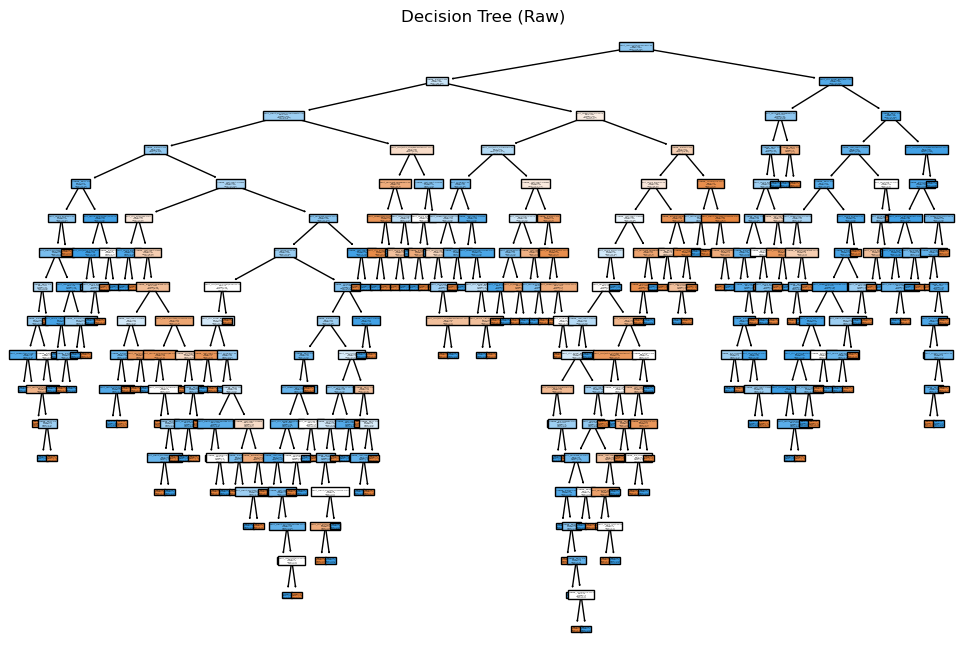

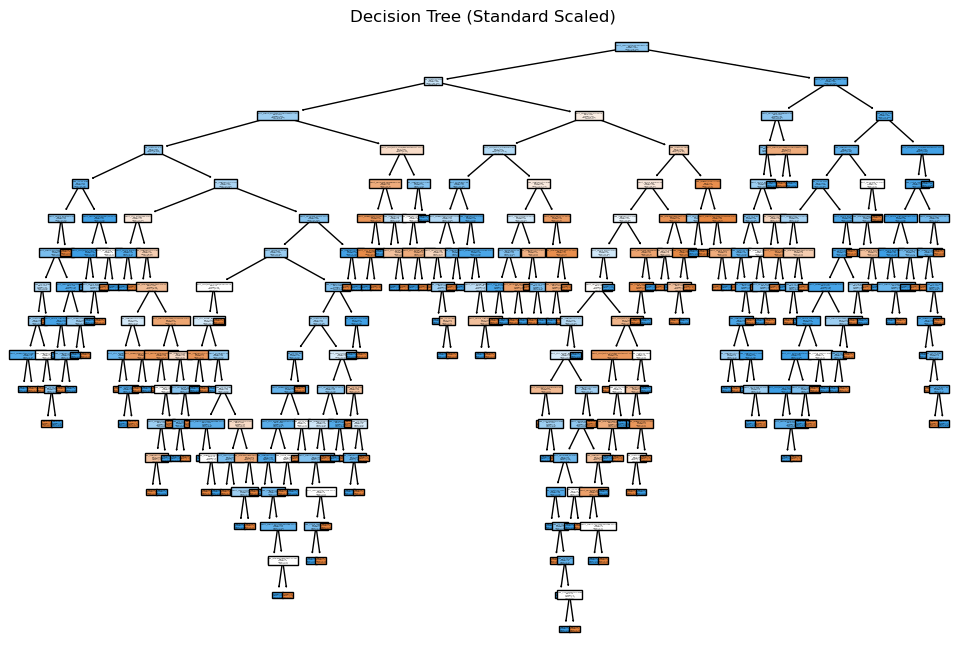

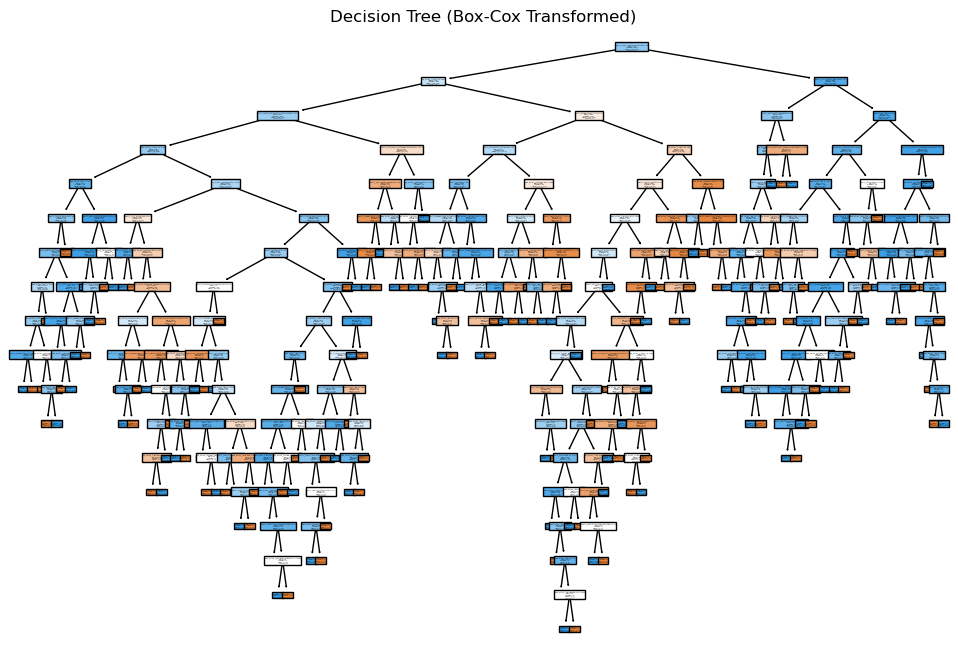

In [5]:
#===SOLUTION===

import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 1. For the raw pipeline: reuse the existing ColumnTransformer (ct)
raw_pipeline = Pipeline([
    ("preprocessor", ct),  # reuse existing ColumnTransformer from previous cell
    ("classifier", DecisionTreeClassifier(random_state=42))
])

# 2. For standard scaling: combine with one-hot encoding
scaled_pipeline = Pipeline([
    ("preprocessor", ColumnTransformer([
        ("num", StandardScaler(), num_features),
        ("onehot", OneHotEncoder(sparse_output=False, drop="first"), cat_features)
    ])),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

# 3. For Box-Cox transformation (only for non-negative features)
boxcox_pipeline = Pipeline([
    ("preprocessor", ColumnTransformer([
        ("num_boxcox", PowerTransformer(method='box-cox'), non_negative_features),
        ("onehot", OneHotEncoder(sparse_output=False, drop="first"), cat_features),
    ])),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

# Helper function for visualization
def plot_decision_tree(pipeline, title):
    plt.figure(figsize=(12, 8))
    feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()
    plot_tree(pipeline.named_steps["classifier"],
              feature_names=feature_names,
              class_names=["bad", "good"],
              filled=True)
    plt.title(title)
    plt.show()

for pipe in [raw_pipeline, scaled_pipeline, boxcox_pipeline]:
    pipe.fit(X, y)  # use original target variable directly

titles = ["Decision Tree (Raw)", 
         "Decision Tree (Standard Scaled)", 
         "Decision Tree (Box-Cox Transformed)"]

for pipe, title in zip([raw_pipeline, scaled_pipeline, boxcox_pipeline], titles):
    plot_decision_tree(pipe, title)

## 4 Benchmark k-NN and Decision Tree with Scaling and Box-Cox Transformation

In the previous exercise, we observed that scaling does not significantly affect the structure or performance of a decision tree. However, for distance-based learners like k-NN, scaling numeric features is essential, as it ensures that all features contribute comparably to distance calculations.
In this exercise, you will perform a benchmark that demonstrates this effect. Specifically:
* Consider the following learners:
    * k-NN (`KNeighborsClassifier`)
    * Decision Tree (`DecisionTreeClassifier`)
* For each learner, train it on:
    * The raw (unscaled) data.
    * The data with Standard Scaling.
    * The data with Box-Cox Transformation.

This leads to a total of 6 models: 2 learners × 3 preprocessing variants.
Finally, compare the models using 10-fold cross-validation and visualize the classification error rates.

<details><summary>Hint 1:</summary>
    You can organize the benchmark conveniently by creating a dictionary where keys are learner names combined with the preprocessing type (e.g., "KNN_scaled") and values are the corresponding pipelines. This helps you systematically train and evaluate multiple models without repeating code.
</details>

<details><summary>Hint 2:</summary>
    If you like, you can implement a helper function: `def create_preprocessor(numeric_transformer: BaseEstimator, num_features: List[str], cat_features: List[str], non_negative_features: Optional[List[str]]=None, use_boxcox: bool = False) -> ColumnTransformer` to reduce the verbosity of the code.
</details>


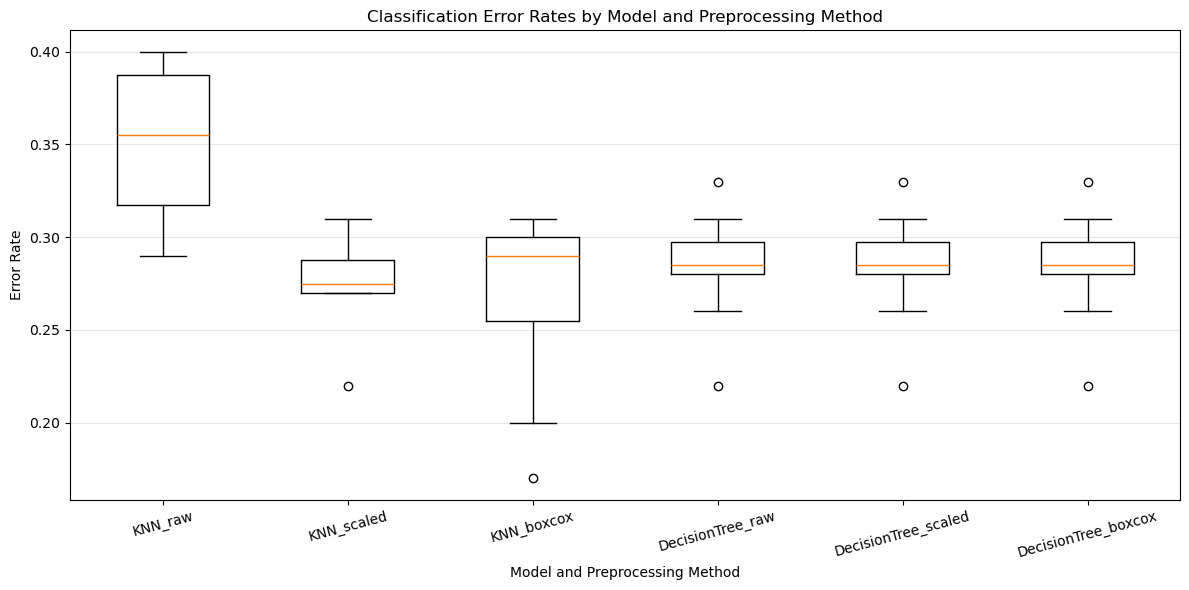

Mean Classification Error:
KNN_raw: 0.3520
KNN_scaled: 0.2750
KNN_boxcox: 0.2690
DecisionTree_raw: 0.2840
DecisionTree_scaled: 0.2840
DecisionTree_boxcox: 0.2840


In [6]:
#===SOLUTION===

import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score


def create_preprocessor(numeric_transformer, num_features, cat_features, non_negative_features=None, use_boxcox=False):
    """Create a preprocessor with specified numeric transformation"""
    if use_boxcox and non_negative_features is not None:
        # For BoxCox, only apply to non-negative features
        return ColumnTransformer([
            ("num", numeric_transformer, non_negative_features),
            ("cat", OneHotEncoder(sparse_output=False, drop="first"), cat_features)
        ])
    else:
        return ColumnTransformer([
            ("num", numeric_transformer, num_features),
            ("cat", OneHotEncoder(sparse_output=False, drop="first"), cat_features)
        ])

def create_pipeline(preprocessor, classifier):
    """Create a pipeline combining preprocessor and classifier"""
    return Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", classifier)
    ])

# Define classifiers
classifiers = {
    "KNN": KNeighborsClassifier(n_neighbors=10),
    "DecisionTree": DecisionTreeClassifier(random_state=2023, max_depth=3)
}

# Define preprocessors for numeric features
numeric_preprocessors = {
    "raw": "passthrough",
    "scaled": StandardScaler(),
    "boxcox": PowerTransformer(method='box-cox')
}

# Create all pipelines
pipelines = {}
for clf_name, clf in classifiers.items():
    for prep_name, prep in numeric_preprocessors.items():
        name = f"{clf_name}_{prep_name}"
        use_boxcox = (prep_name == "boxcox")
        preprocessor = create_preprocessor(
            prep, 
            num_features=num_features, 
            cat_features=cat_features,
            non_negative_features=non_negative_features,
            use_boxcox=use_boxcox
        )
        pipeline = create_pipeline(preprocessor, clf)
        pipelines[name] = pipeline

# Collect cross-validation results
results = {}
for name, pipeline in pipelines.items():
    scores = cross_val_score(pipeline, X, y, cv=10, scoring='accuracy')
    errors = 1 - scores
    results[name] = errors

# Prepare data for boxplot
labels = list(results.keys())
data = [results[key] for key in labels]

# Create boxplot
plt.figure(figsize=(12, 6))
plt.boxplot(data, labels=labels)
plt.title('Classification Error Rates by Model and Preprocessing Method')
plt.ylabel('Error Rate')
plt.xlabel('Model and Preprocessing Method')
plt.xticks(rotation=15)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Print mean error rates for each model
print("Mean Classification Error:")
for label, errors in zip(labels, data):
    print(f"{label}: {np.mean(errors):.4f}")

## Summary

We learned how to apply preprocessing steps such as one-hot encoding, standard scaling, or Box-Cox transformation directly on the dataset using `scikit-learn`'s preprocessing tools. Furthermore, we have seen how to create a Pipeline object that chains preprocessing and a machine learning model, ensuring that all preprocessing steps are automatically applied before training the learner. Finally, we observed that scaling is crucial for distance-based learners like k-NN, while it has little to no effect on decision trees, as their structure and performance remain largely unaffected by feature scaling.